## Setting up the environment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [8]:
df=pd.read_csv("train.csv")
df.head()               

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Understand the Dataset

In [40]:
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


(891, 8)

## Checking missing values

In [48]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## Handle missing values

In [42]:
# Clean column names
df.columns = df.columns.str.strip()

# Fill Age
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin safely
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

## Remove unnecessary columns

In [43]:
df.drop(columns=['Name', 'Ticket', 'PassengerId'], errors='ignore', inplace=True)

## Verifying Cleaning

In [44]:
df.isnull().sum()
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [45]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Univariate Analysis

## 1. Age Distribution

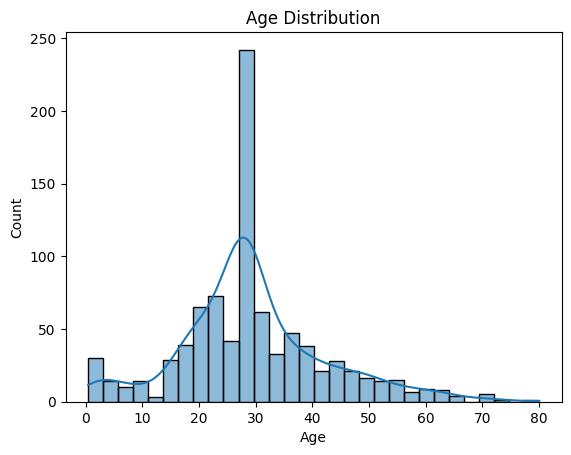

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

## 2. Survival Count

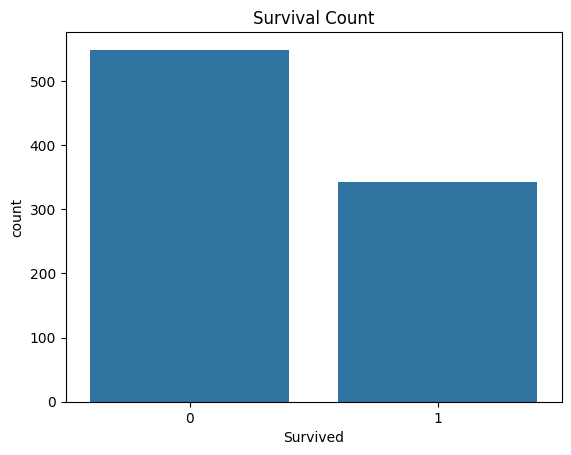

In [47]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

## 3. Passenger Class

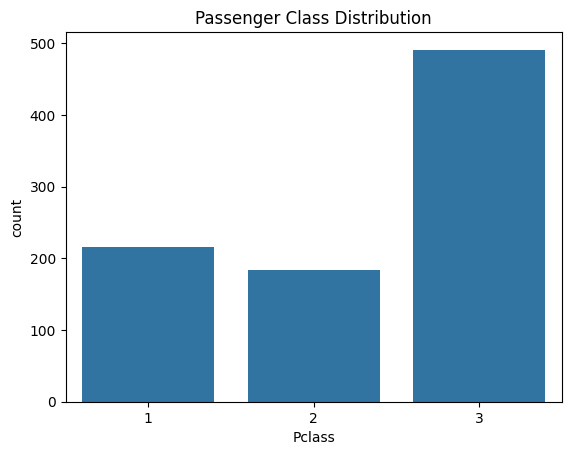

In [28]:
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

# Bivariate Analysis

## 1. Gender vs Survival

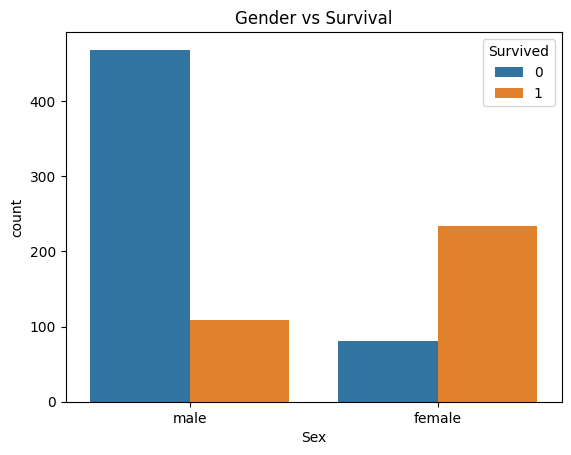

In [29]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

## 2. Class vs Survival

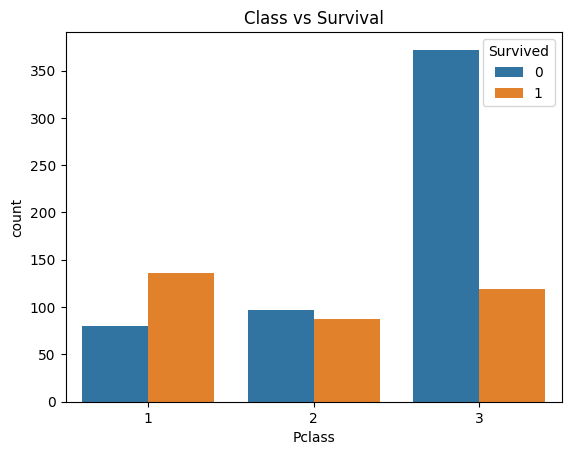

In [30]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Class vs Survival")
plt.show()

## 3. Fare vs Survival

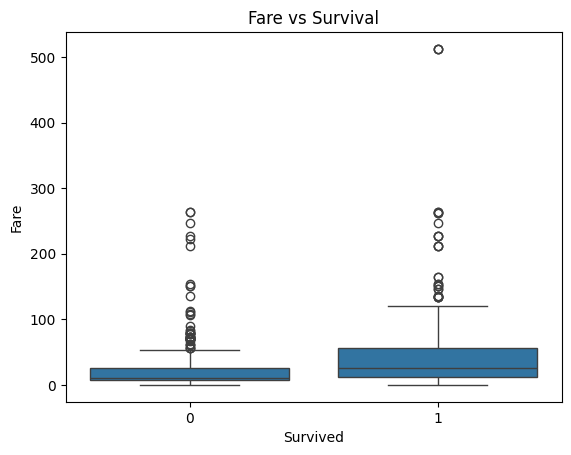

In [50]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

# Multivariate Analysis

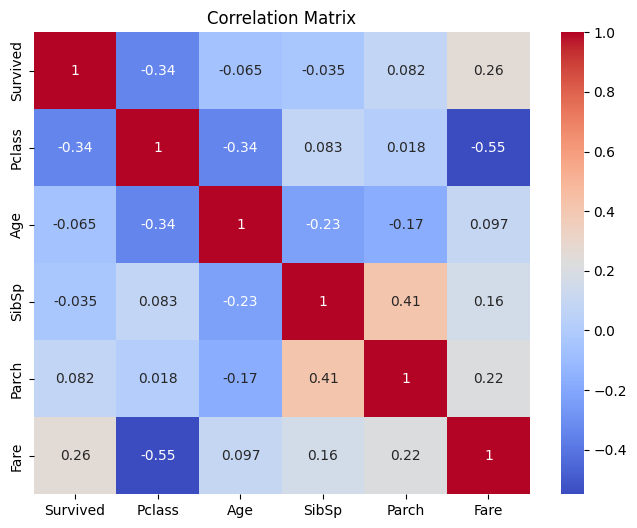

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Key Insights

### - Females had a higher survival rate than males  
### - First-class passengers were more likely to survive  
### - Passengers with higher fares had better survival chances  
### - Younger passengers had slightly higher survival rates  

## Conclusion

### The analysis shows that survival on the Titanic was mainly influenced by gender, passenger class, and fare. Data cleaning improved the dataset quality, and EDA helped identify key patterns.

## Saving the cleaned dataset

In [51]:
df.to_csv("cleaned_titanic.csv", index=False)
print("Cleaned dataset saved as cleaned_titanic.csv")
df.head()

Cleaned dataset saved as cleaned_titanic.csv


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
